In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle
from tensorflow.keras.optimizers import RMSprop, Adam

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import History
import tensorflow as tf
# tf.compat.v1.disable_eager_execution()
tf.config.set_visible_devices([], 'GPU')

history = History()


2026-02-24 11:49:54.139682: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 11:49:56.537643: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-24 11:49:56.541130: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-24 11:50:06.055305: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Preprocess data

In [2]:

data = pd.read_csv("model/spam.csv", encoding='latin-1')
data = data.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
data = data.rename(columns={"v1":"label", "v2":"text"})
data['label_num'] = data.label.map({'ham':0, 'spam':1})

X_train,X_test,y_train,y_test = train_test_split(data["text"],data["label_num"], test_size = 0.2, random_state = 10)


### Vectorize

In [3]:

vect = CountVectorizer()
vect.fit(X_train)
# fn = vect.get_feature_names()

X_train_df = vect.transform(X_train).toarray()
X_test_df = vect.transform(X_test).toarray()



### Build Model

In [6]:
model = Sequential()
model.add(Dense(128, input_dim=X_train_df.shape[1], activation='sigmoid'))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

opt = RMSprop(learning_rate=0.001)    

model.compile(loss='mse',
              optimizer=opt,
              metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 128)               993024    
                                                                 
 dense_7 (Dense)             (None, 64)                8256      
                                                                 
 dense_8 (Dense)             (None, 1)                 65        
                                                                 
Total params: 1001345 (3.82 MB)
Trainable params: 1001345 (3.82 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Train model

In [7]:

history = model.fit(X_train_df, y_train,
          epochs=10,
          batch_size=128, callbacks=[history])

print("Model performance on testing set")
score = model.evaluate(X_test_df, y_test, batch_size=128)

Epoch 1/10
35/35 [==============================] - 1s 11ms/step - loss: 0.1234 - accuracy: 0.8463
Epoch 2/10
35/35 [==============================] - 0s 11ms/step - loss: 0.1138 - accuracy: 0.8661
Epoch 3/10
35/35 [==============================] - 0s 12ms/step - loss: 0.1115 - accuracy: 0.8661
Epoch 4/10
35/35 [==============================] - 0s 11ms/step - loss: 0.1066 - accuracy: 0.8661
Epoch 5/10
35/35 [==============================] - 0s 11ms/step - loss: 0.0958 - accuracy: 0.8663
Epoch 6/10
35/35 [==============================] - 0s 11ms/step - loss: 0.0767 - accuracy: 0.8847
Epoch 7/10
35/35 [==============================] - 0s 12ms/step - loss: 0.0553 - accuracy: 0.9361
Epoch 8/10
35/35 [==============================] - 0s 11ms/step - loss: 0.0396 - accuracy: 0.9578
Epoch 9/10
35/35 [==============================] - 0s 11ms/step - loss: 0.0303 - accuracy: 0.9690
Epoch 10/10
35/35 [==============================] - 0s 11ms/step - loss: 0.0250 - accuracy: 0.9744
Model per

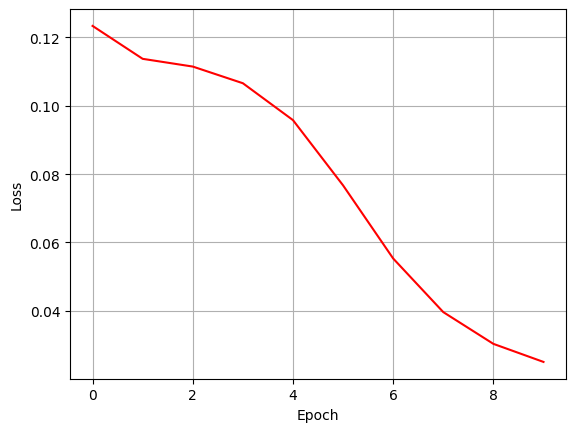

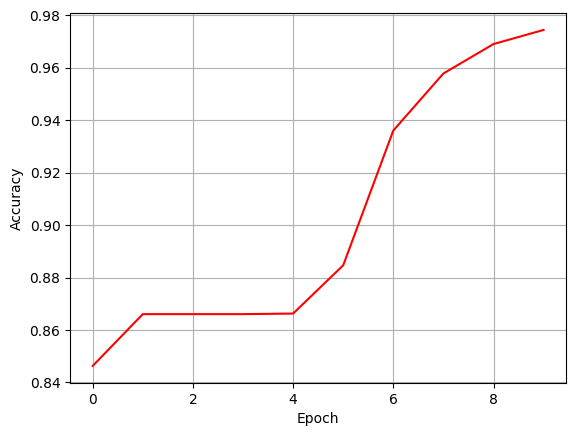

In [8]:
plt.plot(history.history['loss'], c='r')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.show()

# change accuracy to acc
plt.plot(history.history['accuracy'], c='r')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.show()


### Save Model

In [9]:
print(score)
print('saving model')
model.save('/tmp/trained_model')
print('saving vect')
with open('/tmp/vect', 'wb') as f:
    pickle.dump(vect, f)

[0.028380827978253365, 0.9668161273002625]
saving model
INFO:tensorflow:Assets written to: /tmp/trained_model/assets


INFO:tensorflow:Assets written to: /tmp/trained_model/assets


saving vect
